# Прогноз стоимости подержанного автомобиля

Цены указаны в лакхах индийских рупий (1 лакх = 100 000 ₹). Возраст рассчитывается относительно 2020 года, как в исходных данных. Названия столбцов сохранены для совместимости.

### Подключение библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

## Подготовка данных

In [2]:
# Загрузка исходных данных
car_dataset = pd.read_csv("../data/raw/car_data.csv")
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Размер набора данных
car_dataset.shape

(301, 9)

In [4]:
# Типы столбцов и количество непустых значений
car_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [5]:
# Распределение категориальных признаков
print(car_dataset['Fuel_Type'].value_counts())
print()
print(car_dataset['Seller_Type'].value_counts())
print()
print(car_dataset['Transmission'].value_counts())
print()
print(car_dataset['Owner'].value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner
0    290
1     10
3      1
Name: count, dtype: int64


In [6]:
car_dataset.describe(include='all')

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


## Проверка пропущенных значений

In [7]:
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

В исходном наборе данных нет пропущенных значений.

In [8]:
# Возраст автомобиля относительно базового 2020 года
car_dataset['Years_old'] = 2020 - car_dataset.Year

# Удаление года после расчёта возраста
car_dataset.drop(['Year'],axis=1,inplace=True)

In [9]:
car_dataset.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Years_old
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


# Исследование данных

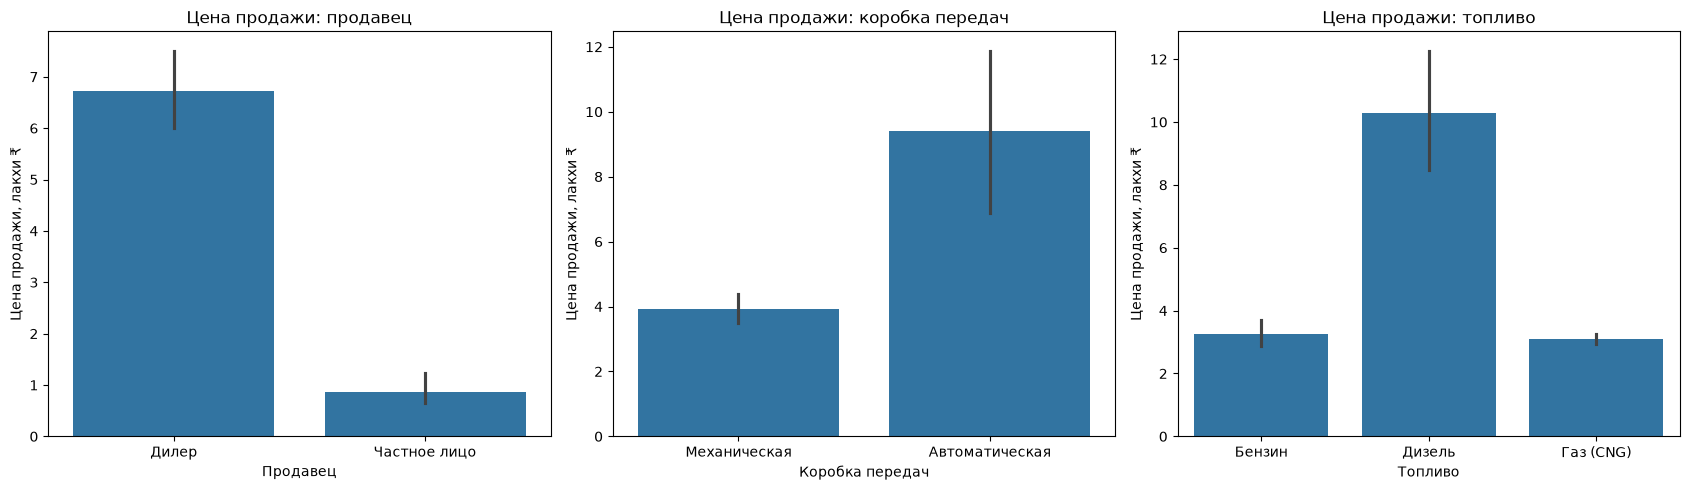

In [10]:
# Связь цены продажи с категориальными признаками
plot_data = car_dataset.replace({
    'Seller_Type': {'Dealer': 'Дилер', 'Individual': 'Частное лицо'},
    'Transmission': {'Manual': 'Механическая', 'Automatic': 'Автоматическая'},
    'Fuel_Type': {'Petrol': 'Бензин', 'Diesel': 'Дизель', 'CNG': 'Газ (CNG)'},
})
plt.figure(figsize=(17, 5))
for number, (column, title) in enumerate([
    ('Seller_Type', 'Продавец'), ('Transmission', 'Коробка передач'),
    ('Fuel_Type', 'Топливо'),
], start=1):
    plt.subplot(1, 3, number)
    sns.barplot(data=plot_data, x=column, y='Selling_Price')
    plt.xlabel(title)
    plt.ylabel('Цена продажи, лакхи ₹')
    plt.title('Цена продажи: ' + title.lower())
plt.tight_layout()
plt.show()


- На графиках автомобили дилеров имеют более высокую цену продажи, чем автомобили частных продавцов.
- Автомобили с автоматической коробкой дороже автомобилей с механической коробкой.
- Дизельные автомобили имеют более высокие цены, чем бензиновые и автомобили на CNG.

Это наблюдения в данном датасете, а не причинные зависимости.

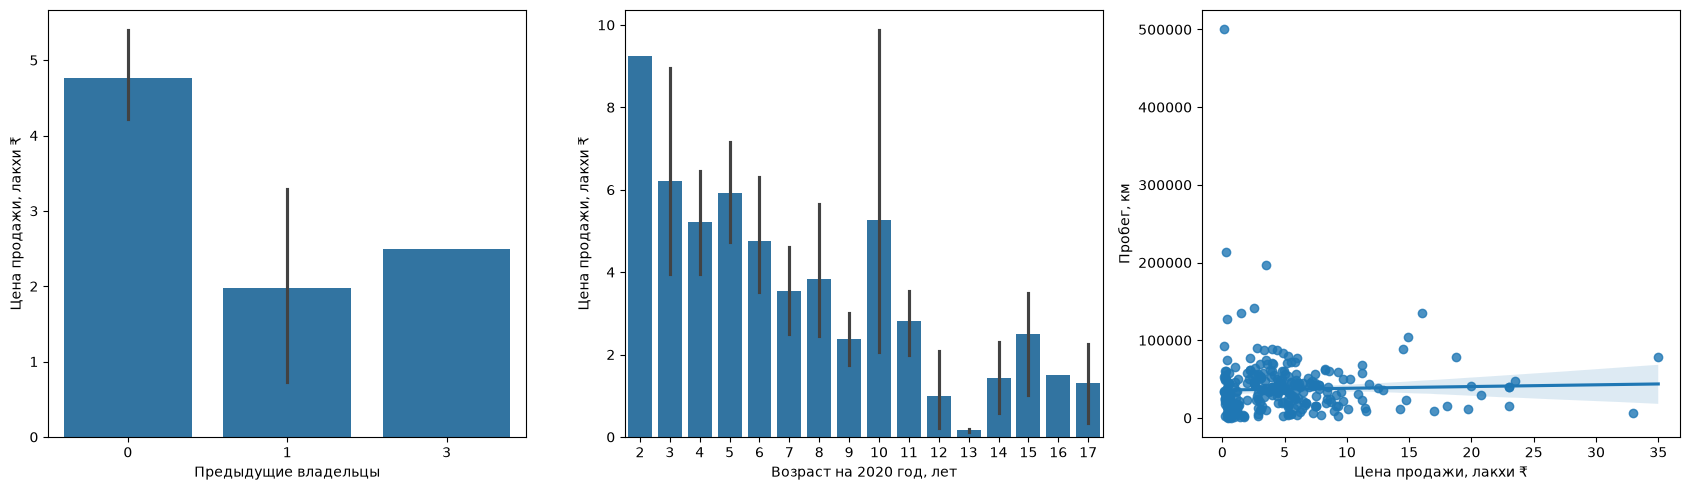

In [11]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 3, 1)
sns.barplot(data=car_dataset, x='Owner', y='Selling_Price')
plt.xlabel('Предыдущие владельцы')
plt.ylabel('Цена продажи, лакхи ₹')
plt.subplot(1, 3, 2)
sns.barplot(data=car_dataset, x='Years_old', y='Selling_Price')
plt.xlabel('Возраст на 2020 год, лет')
plt.ylabel('Цена продажи, лакхи ₹')
plt.subplot(1, 3, 3)
sns.regplot(data=car_dataset, x='Selling_Price', y='Kms_Driven')
plt.xlabel('Цена продажи, лакхи ₹')
plt.ylabel('Пробег, км')
plt.tight_layout()
plt.show()


- Автомобили с меньшим количеством предыдущих владельцев обычно имеют более высокую цену.
- Цена продажи в целом снижается с возрастом автомобиля.
- На графике видна связь пробега и цены продажи.

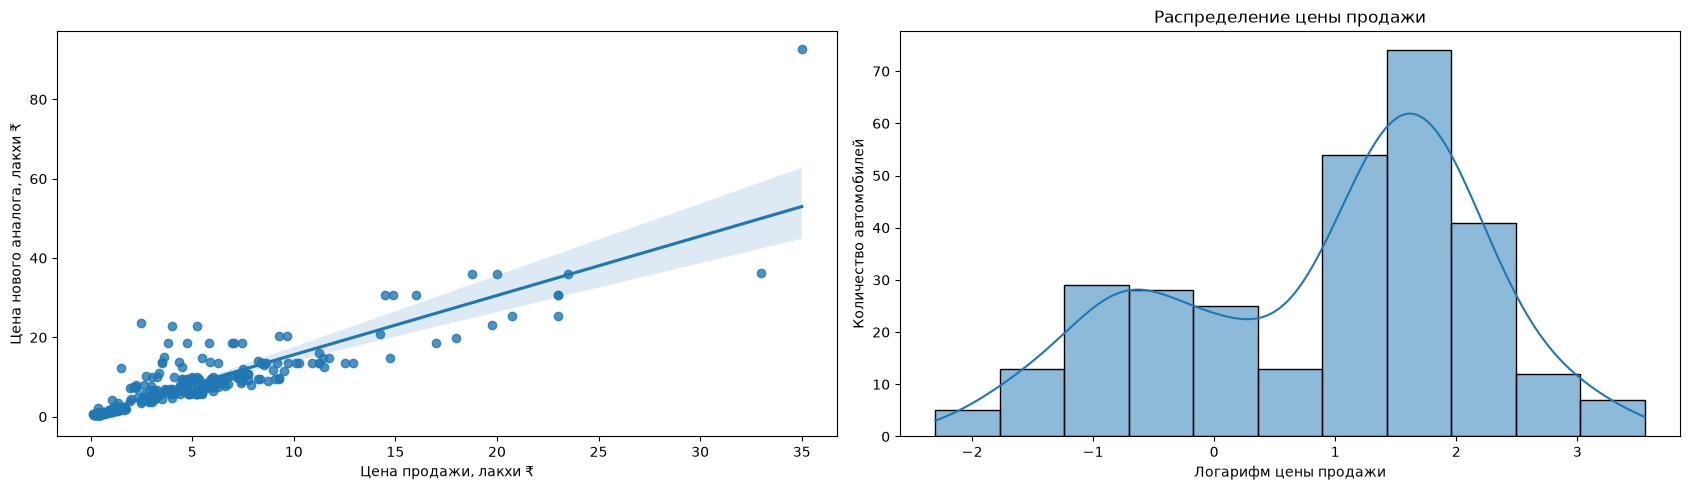

In [12]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
sns.regplot(data=car_dataset, x='Selling_Price', y='Present_Price')
plt.xlabel('Цена продажи, лакхи ₹')
plt.ylabel('Цена нового аналога, лакхи ₹')
plt.subplot(1, 2, 2)
sns.histplot(np.log(car_dataset['Selling_Price']), kde=True)
plt.xlabel('Логарифм цены продажи')
plt.ylabel('Количество автомобилей')
plt.title('Распределение цены продажи')
plt.tight_layout()
plt.show()


- Цена продажи обычно растёт вместе с ценой нового аналога.

##### Обработка категориальных признаков

In [13]:
# Исключение названия автомобиля из признаков исходной модели
car_dataset = car_dataset.drop(['Car_Name'],axis=1)

In [14]:
# Кодирование категорий бинарными столбцами
newCar_dataset = pd.get_dummies(car_dataset, drop_first=True, dtype=float)
newCar_dataset.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Years_old,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,0.0,1.0,0.0,1.0
1,4.75,9.54,43000,0,7,1.0,0.0,0.0,1.0
2,7.25,9.85,6900,0,3,0.0,1.0,0.0,1.0
3,2.85,4.15,5200,0,9,0.0,1.0,0.0,1.0
4,4.60,6.87,42450,0,6,1.0,0.0,0.0,1.0


# Проверка мультиколлинеарности с помощью VIF

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
features = newCar_dataset.iloc[:,1:]

vif = pd.DataFrame()
vif['Признак'] = features.columns
vif['VIF'] = [variance_inflation_factor(features.to_numpy(dtype=float),i) for i in range(features.shape[1])]
vif

,Признак,VIF
0,Present_Price,1.836927
1,Kms_Driven,1.517916
2,Owner,1.056734
3,Years_old,1.482347
4,Fuel_Type_Diesel,25.182719
5,Fuel_Type_Petrol,25.026007
6,Seller_Type_Individual,1.449644
7,Transmission_Manual,1.196263


In [16]:
# Изучение корреляций перед исключением признаков
corr_matrix = newCar_dataset.corr()
corr_matrix['Selling_Price'].sort_values(ascending=False)

Selling_Price             1.000000
Present_Price             0.878983
Fuel_Type_Diesel          0.552339
Kms_Driven                0.029187
Owner                    -0.088344
Years_old                -0.236141
Transmission_Manual      -0.367128
Fuel_Type_Petrol         -0.540571
Seller_Type_Individual   -0.550724
Name: Selling_Price, dtype: float64

In [17]:
# Исключение признаков по подходу исходного проекта
# Пробег и отдельный индикатор бензина не используются в модели
newCar_dataset = newCar_dataset.drop(['Fuel_Type_Petrol','Kms_Driven'],axis=1)

In [18]:
# Повторная проверка мультиколлинеарности
from statsmodels.stats.outliers_influence import variance_inflation_factor
features = newCar_dataset.iloc[:,1:]

vif = pd.DataFrame()
vif['Признак'] = features.columns
vif['VIF'] = [variance_inflation_factor(features.to_numpy(dtype=float),i) for i in range(features.shape[1])]
vif

,Признак,VIF
0,Present_Price,1.834416
1,Owner,1.056667
2,Years_old,1.047863
3,Fuel_Type_Diesel,1.332563
4,Seller_Type_Individual,1.438317
5,Transmission_Manual,1.169327


- После удаления признаков значения VIF ниже 5. В исходном проекте это используется как ориентир для оценки мультиколлинеарности.

In [19]:
X = newCar_dataset.drop('Selling_Price', axis = 1)
Y = newCar_dataset['Selling_Price']
print(X.shape)
print(Y.shape)

(301, 6)
(301,)


##### Оценка важности признаков

In [20]:
# Оценка важности признаков: большее значение означает больший вклад в модель
# Оценка важности признаков: большее значение означает больший вклад в модель
from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor(random_state=42)
model.fit(X,Y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split ind

In [21]:
model.feature_importances_

array([0.42214314, 0.00093907, 0.10929564, 0.21306805, 0.12854462,
       0.12600949])

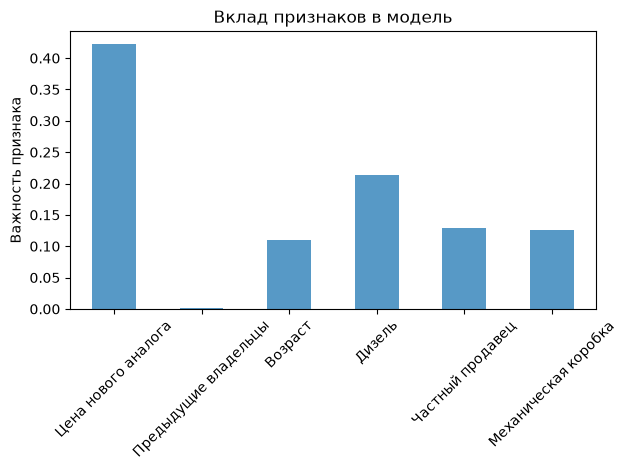

In [22]:
feature_labels = {
    'Present_Price': 'Цена нового аналога', 'Owner': 'Предыдущие владельцы',
    'Years_old': 'Возраст', 'Fuel_Type_Diesel': 'Дизель',
    'Seller_Type_Individual': 'Частный продавец', 'Transmission_Manual': 'Механическая коробка',
}
pd.Series(model.feature_importances_, index=[feature_labels[c] for c in X.columns]).plot(kind='bar', alpha=0.75, rot=45)
plt.ylabel('Важность признака')
plt.title('Вклад признаков в модель')
plt.tight_layout()
plt.show()


# Оценка моделей

##### Разделение на обучающую и тестовую выборки

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.1,random_state = 42)

In [24]:
X_train.head()

,Present_Price,Owner,Years_old,Fuel_Type_Diesel,Seller_Type_Individual,Transmission_Manual
282,14.00,0,6,1.0,0.0,1.0
163,0.95,0,10,0.0,1.0,1.0
42,7.15,0,12,0.0,0.0,1.0
17,10.79,0,4,1.0,0.0,1.0
266,7.00,0,6,0.0,0.0,1.0


# Сравнение регрессионных моделей

# 1. Линейная регрессия

In [25]:
from sklearn.linear_model import LinearRegression
# Создание линейной регрессии
lin_reg_model = LinearRegression()

lin_reg_model.fit(X_train,Y_train)

# Предсказания на обучающей выборке
training_data_prediction_lr = lin_reg_model.predict(X_train)

# Расчёт R² и RMSE на обучающей выборке
error_score = metrics.r2_score(Y_train,training_data_prediction_lr)
rmse = np.sqrt(metrics.mean_squared_error(Y_train,training_data_prediction_lr))
print("R²:",error_score)
print("RMSE (лакхи ₹):",rmse)

R²: 0.8833645728428189
RMSE (лакхи ₹): 1.7711334279164754


# 2. Случайный лес

In [26]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)

# Обучение случайного леса
rf_model.fit(X_train,Y_train)

# Предсказания на обучающей выборке
training_data_prediction_rf = rf_model.predict(X_train)

# Расчёт R² и RMSE на обучающей выборке
error_score = metrics.r2_score(Y_train,training_data_prediction_rf)
rmse = np.sqrt(metrics.mean_squared_error(Y_train,training_data_prediction_rf))
print("R²:",error_score)
print("RMSE (лакхи ₹):",rmse)

R²: 0.9864678243276921
RMSE (лакхи ₹): 0.6032812828968981


# 3. Lasso-регрессия

In [27]:
# Создание Lasso-регрессии
lasso_reg_model = Lasso()

lasso_reg_model.fit(X_train,Y_train)

# Предсказания на обучающей выборке
training_data_prediction_lasso = lasso_reg_model.predict(X_train)

# Расчёт R² и RMSE на обучающей выборке
error_score = metrics.r2_score(Y_train,training_data_prediction_lasso)
rmse = np.sqrt(metrics.mean_squared_error(Y_train,training_data_prediction_lasso))
print("R²:",error_score)
print("RMSE (лакхи ₹):",rmse)

R²: 0.8449110465301957
RMSE (лакхи ₹): 2.0423326037869014


In [28]:
some_data = X_train.iloc[:5]
some_labels = Y_train.iloc[:5]

In [29]:
rf_model.predict(some_data)

array([8.67306667, 0.454     , 2.122     , 7.7429    , 3.82329167])

In [30]:
list(some_labels)

[8.25, 0.45, 1.95, 7.75, 3.65]

##### Сравним модели и продолжим подбор параметров случайного леса. Окончательное качество оценим на отдельной тестовой выборке.

# Подбор гиперпараметров через RandomizedSearchCV

In [31]:
from sklearn.model_selection import RandomizedSearchCV

# Количество деревьев
n_estimators = [int(x) for x in np.linspace(start=100, stop=1200,num=12)]
# Доля или число признаков при разбиении
max_features = [1.0, 'sqrt']
# Максимальная глубина дерева
max_depth = [int(x) for x in np.linspace(5,30,num=6)]
# Минимальное число объектов для разбиения узла
min_samples_split = [2,5,10,15,100]
# Минимальное число объектов в листе
min_samples_leaf = [1,2,5,10]

random_grid = {'n_estimators':n_estimators,
              'max_features':max_features,
              'max_depth':max_depth,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf}
print(random_grid)

{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], 'max_features': [1.0, 'sqrt'], 'max_depth': [5, 10, 15, 20, 25, 30], 'min_samples_split': [2, 5, 10, 15, 100], 'min_samples_leaf': [1, 2, 5, 10]}


In [32]:
# Случайный поиск гиперпараметров с перекрёстной проверкой
rf_randomized = RandomizedSearchCV(estimator = rf_model, param_distributions = random_grid, n_iter = 10, cv = 5,verbose = 0, random_state = 42, n_jobs = 1)

In [33]:
rf_randomized.fit(X_train,Y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': [1.0, 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multi

In [34]:
# Лучшие параметры по результатам поиска
rf_randomized.best_params_

{'n_estimators': 1000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 25}

In [35]:
rf_randomized_predictions = rf_randomized.predict(X_train)

In [36]:
# Расчёт R² и RMSE на обучающей выборке
error_score = metrics.r2_score(Y_train,rf_randomized_predictions)
rmse = np.sqrt(metrics.mean_squared_error(Y_train,rf_randomized_predictions))
print("R²:",error_score)
print("RMSE (лакхи ₹):",rmse)

R²: 0.9837221645066465
RMSE (лакхи ₹): 0.6616592149877019


# Проверка модели на тестовой выборке

In [37]:
final_predictions = rf_randomized.predict(X_test)
error_score = metrics.r2_score(Y_test,final_predictions)
rmse = np.sqrt(metrics.mean_squared_error(Y_test,final_predictions))
print("R²:",error_score)
print("RMSE (лакхи ₹):",rmse)

R²: 0.9224278877745201
RMSE (лакхи ₹): 1.0756095446070457


#### Сравнение прогнозов с фактическими ценами

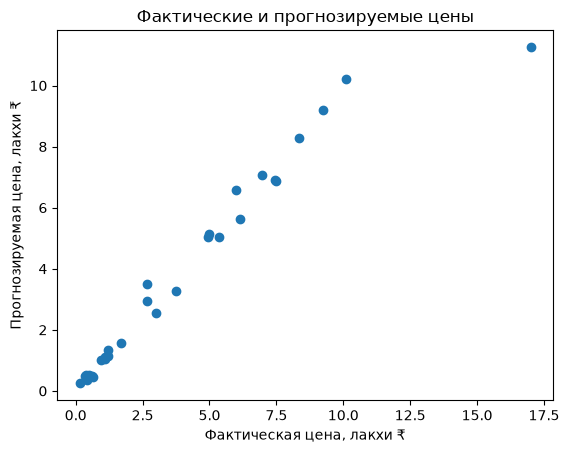

In [38]:
plt.scatter(Y_test, final_predictions)
plt.xlabel('Фактическая цена, лакхи ₹')
plt.ylabel('Прогнозируемая цена, лакхи ₹')
plt.title('Фактические и прогнозируемые цены')
plt.show()


# Сохранение модели

In [39]:
from pathlib import Path
Path("../artifacts").mkdir(exist_ok=True)
import joblib
joblib.dump(rf_randomized.best_estimator_, '../artifacts/notebook_model.joblib')
# Загрузка модели для предсказаний
model = joblib.load('../artifacts/notebook_model.joblib')


# Получение предсказаний

In [40]:
def predictions(PresentPrice, YearsOld, Owner, FuelType, SellerType, TransmissionManual):
    """Прогноз в лакхах ₹: признаки передаются в порядке обучения."""
    row = pd.DataFrame([[
        float(PresentPrice), int(Owner), int(YearsOld), int(FuelType),
        int(SellerType), int(TransmissionManual),
    ]], columns=X.columns)
    return model.predict(row)


In [41]:
predictions(25, 14, 1, 0, 0, 0)

array([11.13806171])

In [42]:
predictions(14, 4,1, 0, 1, 1)

array([4.75353643])

# Выводы

- Цена нового аналога связана с прогнозируемой ценой продажи.
- Более старые автомобили в этом датасете обычно стоят дешевле.
- Цена зависит от типа топлива, коробки передач и продавца.
